In [14]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio as rio
import xarray as xr

from fnmatch import fnmatch
import re

from rasterio.warp import calculate_default_transform, reproject, Resampling

import tarfile as tar
import os

import matplotlib.pyplot as plt

In [15]:
test_tar_path = "/capstone/wildfire_prep/data/landsat/test/raw_tar/LC08_L2SP_042036_20190724_20200827_02_T1.tar"
output_direct = "/capstone/wildfire_prep/data/landsat/test/unpack"

In [16]:

with tar.open(test_tar_path, "r") as tar:
    tar.extractall(path=output_direct)

print(f"Files extracted to {output_direct}")


/tmp/ipykernel_3559169/3313315184.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=output_direct)


Files extracted to /capstone/wildfire_prep/data/landsat/test/unpack


In [17]:
# Path to an extracted .TIF file
tif_file = "/capstone/wildfire_prep/data/landsat/test/unpack/LC08_L2SP_042036_20190724_20200827_02_T1_SR_B2.TIF"

# Open the GeoTIFF file
with rio.open(tif_file) as dataset:
    print(dataset.meta)  # Metadata (e.g., dimensions, crs, etc.)
    image_data = dataset.read()  # Read the data as a NumPy array

print(f"Loaded image with shape: {image_data.shape}")


{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 7831, 'height': 7961, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]'), 'transform': Affine(30.0, 0.0, 122685.0,
       0.0, -30.0, 3952515.0)}
Loaded image with shape: (1, 7961, 7831)


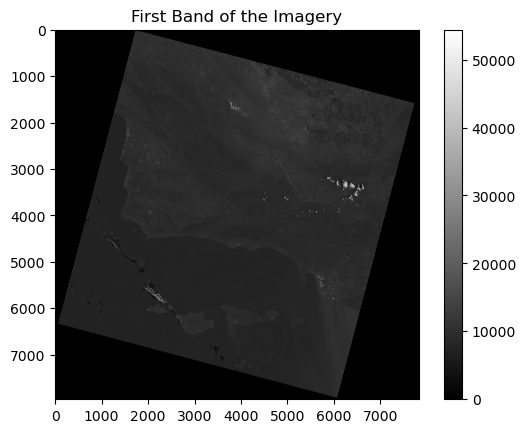

In [18]:
# Plot the first band (or any specific band)
plt.imshow(image_data[0], cmap="gray")
plt.title("First Band of the Imagery")
plt.colorbar()
plt.show()


In [19]:
# image_data

In [20]:
tif_path = "/capstone/wildfire_prep/data/landsat/test/unpack"

# File paths for individual bands
red_file = f"{tif_path}/LC08_L2SP_042036_20190724_20200827_02_T1_SR_B4.TIF"
green_file = f"{tif_path}/LC08_L2SP_042036_20190724_20200827_02_T1_SR_B3.TIF"
blue_file = f"{tif_path}/LC08_L2SP_042036_20190724_20200827_02_T1_SR_B2.TIF"

# Open each band and read data
with rio.open(red_file) as red_src:
    red_band = red_src.read()

with rio.open(green_file) as green_src:
    green_band = green_src.read()

with rio.open(blue_file) as blue_src:
    blue_band = blue_src.read()

print("Bands loaded successfully!")

Bands loaded successfully!


In [21]:
# Stack bands into an RGB array
rgb_image = np.stack((red_band, green_band, blue_band), axis= -1).squeeze()

print(f"RGB image shape: {rgb_image.shape}")  # Should be (height, width, 3)

# rgb_xr = xr.DataArray(rgb_image)

RGB image shape: (7961, 7831, 3)


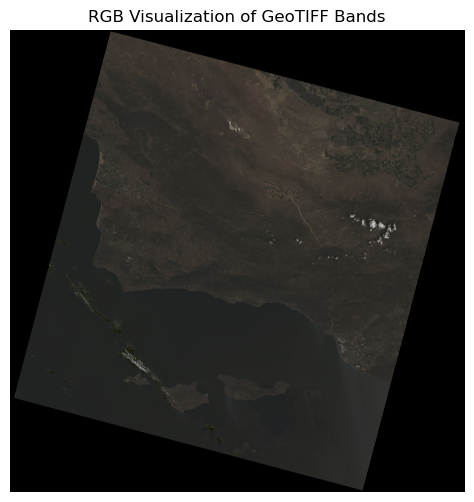

In [22]:
# Plot the RGB image
plt.figure(figsize=(8, 6))
plt.imshow(rgb_image/np.max(rgb_image))
plt.title("RGB Visualization of GeoTIFF Bands")
plt.axis("off")  # Turn off axis for cleaner visualization
plt.show()

In [23]:
# print(red_src.crs)
# print(red_src.transform)
# rgb_image.dtype
rgb_image.shape

(7961, 7831, 3)

In [24]:
height, width, bands = rgb_image.shape
crs = red_src.crs
transform = red_src.transform
dtype = rgb_image.dtype


new_output_path = "/capstone/wildfire_prep/data/landsat/test/export/test_export_tif.tif"

# # Write the 3D array as a GeoTIFF
# with rio.open(
#     new_output_path,
#     "w",
#     driver="GTiff",
#     height=height,
#     width=width,
#     count=bands,  # Number of bands
#     dtype=dtype,  # Data type of your array
#     crs=crs,  # Coordinate Reference System
#     transform=transform,  # Geotransform
# ) as dst:
    
#     # Write each channel to a separate band
#     for i in range(bands):
#         dst.write(rgb_image[:, :, i], indexes=i + 1)  # Band index starts at 1

# print(f"GeoTIFF created at: {new_output_path}")


In [25]:
# bands

In [26]:
with rio.open(new_output_path) as dst:
    print(f"CRS: {dst.crs}")
    print(f"Transform: {dst.transform}")
    print(f"Shape: {dst.height} x {dst.width} x {dst.count}")

    new_test_tif = dst.read()

new_test_tif = np.transpose(new_test_tif, (1, 2, 0))
new_test_tif.shape


CRS: EPSG:32611
Transform: | 30.00, 0.00, 122685.00|
| 0.00,-30.00, 3952515.00|
| 0.00, 0.00, 1.00|
Shape: 7961 x 7831 x 10


(7961, 7831, 10)

TypeError: Invalid shape (7961, 7831, 10) for image data

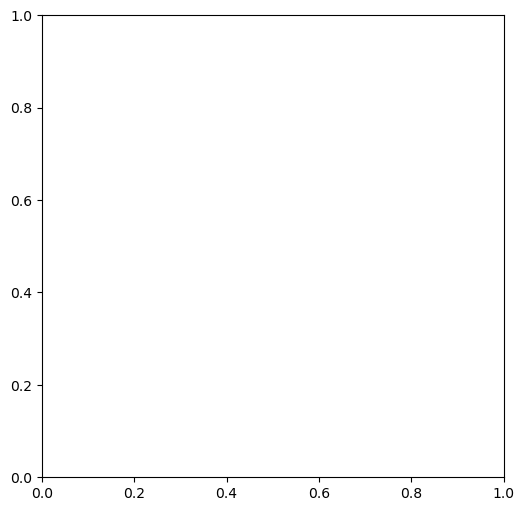

In [27]:
plt.figure(figsize=(8, 6))
plt.imshow(new_test_tif/np.max(new_test_tif))
plt.title("RGB Visualization of GeoTIFF Bands")
# plt.axis("off")  # Turn off axis for cleaner visualization
plt.show()

In [ ]:
new_test_tif.shape

(7961, 7831, 3)

In [ ]:
# Extract geotransform
with rio.open(new_output_path) as src:
    transform = src.transform
    image_data = src.read()

# Get dimensions
height, width = image_data.shape[1], image_data.shape[2]

# Generate coordinate arrays
x_coords = np.arange(width) * transform.a + transform.c  # Longitude
y_coords = np.arange(height) * transform.e + transform.f  # Latitude

# Create a meshgrid for coordinates (optional for advanced plotting)
lon, lat = np.meshgrid(x_coords, y_coords)


In [ ]:
image_data.shape

(3, 7961, 7831)

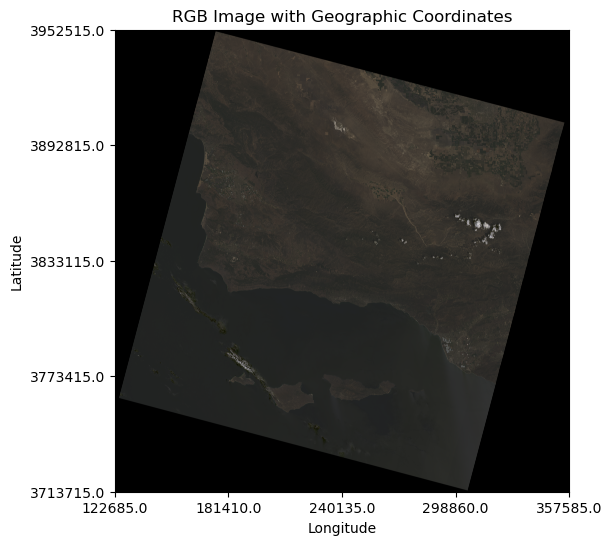

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(image_data.transpose(1, 2, 0)/np.max(image_data.transpose(1, 2, 0)))  # Transpose to (height, width, channels)
plt.title("RGB Image with Geographic Coordinates")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Set axis ticks to match the coordinates
plt.xticks(np.linspace(0, width, num=5), labels=np.linspace(x_coords[0], x_coords[-1], num=5))
plt.yticks(np.linspace(0, height, num=5), labels=np.linspace(y_coords[0], y_coords[-1], num=5))

plt.show()

In [ ]:
# Open the GeoTIFF file
with rio.open(new_output_path) as src:
    transform = src.transform  # Affine transform
    crs = src.crs  # Coordinate Reference System
    image_data = src.read()  # Shape: (3, height, width)

# Get the dimensions
bands, height, width = image_data.shape
print(f"Image shape: {image_data.shape}")

Image shape: (3, 7961, 7831)


In [ ]:
# Generate pixel coordinate arrays
y_indices, x_indices = np.arange(height), np.arange(width)

# Calculate longitude (x) and latitude (y) values
lon = transform.c + x_indices * transform.a  # Longitude array
lat = transform.f + y_indices * transform.e  # Latitude array

In [ ]:
lon

array([122685., 122715., 122745., ..., 357525., 357555., 357585.])

In [ ]:
# Transpose the data from (bands, height, width) to (height, width, bands)
rgb_data = np.transpose(image_data, (1, 2, 0))  # Shape: (height, width, bands)

# Create an xarray.DataArray
rgb_xr = xr.DataArray(
    data=rgb_data,
    dims=("lat", "lon", "band"),
    coords={
        "lat": lat,  # Latitude values
        "lon": lon,  # Longitude values
        "band": ["red", "green", "blue"]  # Band names
    },
    attrs={
        "crs": str(crs),  # Add CRS as metadata
        "description": "RGB Image Data"
    }
)

rgb_xr.crs

'EPSG:32611'

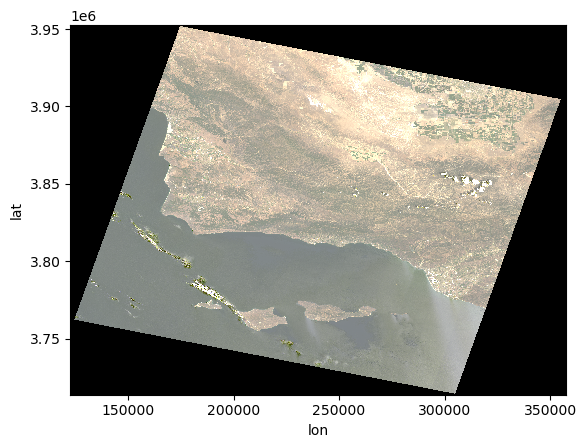

In [ ]:
rgb_xr.plot.imshow(robust=True)

In [ ]:
reproject_output_path = "/capstone/wildfire_prep/data/landsat/test/export/test_reproject_tif.tif"

with rio.open(new_output_path) as src: 
    print(f"CRS: {src.crs}")
    print(f"Bounds: {src.bounds}")
    print(f"Width/Height: {src.width}/{src.height}")
    print(f"left bounds: {src.bounds[0]}")
    print(f"bottome bounds: {src.bounds[1]}")
    print(f"right bounds: {src.bounds[2]}")
    print(f"top bounds: {src.bounds[3]}")
    transform, width, height = calculate_default_transform(
        src_crs = src.crs,
        dst_crs = "EPSG:4326",
        width = src.width, height = src.height,
        left = src.bounds[0],
        bottom = src.bounds[1], 
        right = src.bounds[2], 
        top = src.bounds[3]
    )

    kwargs = src.meta.copy()
    kwargs.update({
        "crs": "EPSG:4326", 
        "transform": transform,
        "width": width,
        "height": height
    })

    # Write reprojected file
    with rio.open(reproject_output_path, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source = rio.band(src, i),
                destination = rio.band(dst, i),
                src_transform = src.transform,
                src_crs = src.crs,
                dst_transform = transform,
                dst_crs = "EPSG:4326",
                resampling = Resampling.nearest
            )


CRS: EPSG:32611
Bounds: BoundingBox(left=122685.0, bottom=3713685.0, right=357615.0, top=3952515.0)
Width/Height: 7831/7961
left bounds: 122685.0
bottome bounds: 3713685.0
right bounds: 357615.0
top bounds: 3952515.0


In [ ]:
with rio.open(new_output_path) as src: 
    print(src.meta["crs"])

EPSG:32611


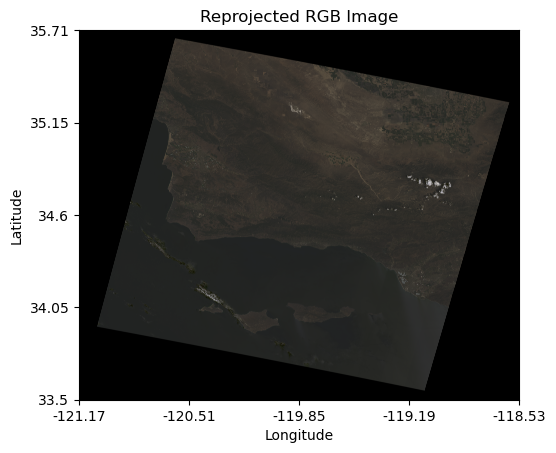

In [ ]:
with rio.open(reproject_output_path) as src:
    image_data = src.read()
    transform = src.transform

# Generate lat/lon axes
height, width = image_data.shape[1], image_data.shape[2]
lon = np.linspace(transform.c, transform.c + width * transform.a, width)
lat = np.linspace(transform.f, transform.f + height * transform.e, height)

# Plot the RGB image
rgb_image = np.transpose(image_data, (1, 2, 0))  # (height, width, bands)
plt.imshow(rgb_image/np.max(rgb_image))
plt.xticks(np.linspace(0, width, 5), labels=np.round(np.linspace(lon[0], lon[-1], 5), 2))
plt.yticks(np.linspace(0, height, 5), labels=np.round(np.linspace(lat[0], lat[-1], 5), 2))
plt.title("Reprojected RGB Image")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
def extract_tar(tar_path, output_path): 
    
    with tar.open(tar_path, "r") as tar:
        tar.extractall(path = output_path)

    print(f"Files extracted to {output_direct}")


In [ ]:
band_file_list = []

for root, _, files in os.walk("/capstone/wildfire_prep/data/landsat/test/unpack"):
    for file in files:
        if fnmatch(file, "*SR*_B?.TIF"):
            band_file_list.append(file)
        elif fnmatch(file, "*QA*"): 
            band_file_list.append(file)

band_file_list

['LC08_L2SP_042036_20190724_20200827_02_T1_SR_B3.TIF',
 'LC08_L2SP_042036_20190724_20200827_02_T1_ST_QA.TIF',
 'LC08_L2SP_042036_20190724_20200827_02_T1_SR_B7.TIF',
 'LC08_L2SP_042036_20190724_20200827_02_T1_SR_B6.TIF',
 'LC08_L2SP_042036_20190724_20200827_02_T1_SR_B5.TIF',
 'LC08_L2SP_042036_20190724_20200827_02_T1_QA_PIXEL.TIF',
 'LC08_L2SP_042036_20190724_20200827_02_T1_SR_QA_AEROSOL.TIF',
 'LC08_L2SP_042036_20190724_20200827_02_T1_SR_B2.TIF',
 'LC08_L2SP_042036_20190724_20200827_02_T1_SR_B1.TIF',
 'LC08_L2SP_042036_20190724_20200827_02_T1_QA_RADSAT.TIF',
 'LC08_L2SP_042036_20190724_20200827_02_T1_SR_B4.TIF']

In [ ]:
band_var_list = []

for name in band_file_list:
    curr_path = root + "/" + name

    # Use regex to extract 'B_' or 'QA_' components directly
    match = re.search(r'B\d|QA_[A-Za-z0-9_]+', name)
    if match:
        landsat_var_name = match.group()  # Extract matched substring

        # Open the corresponding file and store the data in a variable
        with rio.open(curr_path) as src:
            locals()[landsat_var_name[0]] = src.read()

        band_var_list.append(landsat_var_name)  # Debugging output

band_var_list

['B3',
 'B7',
 'B6',
 'B5',
 'QA_PIXEL',
 'QA_AEROSOL',
 'B2',
 'B1',
 'QA_RADSAT',
 'B4']

In [ ]:
band_order_list = []
error_i = 0

for i in band_var_list:

    try:
        rank = int(i[-1])
        band_order_list.append(rank)

    except ValueError:
        rank = 999 + error_i
        band_order_list.append(rank)
        error_i = error_i + 1

band_var_list, band_order_list = zip(*sorted(zip(band_var_list, band_order_list)))


In [ ]:
band_var_list

('B1',
 'B2',
 'B3',
 'B4',
 'B5',
 'B6',
 'B7',
 'QA_AEROSOL',
 'QA_PIXEL',
 'QA_RADSAT')

In [ ]:
full_stack = np.stack((B1, B2, B3, B4, B5, B6, B7), axis= -1).squeeze()

print(full_stack.shape)



(7961, 7831, 7)


In [ ]:
with rio.open(curr_path) as src:
    height, width, bands = full_stack.shape
    crs = src.crs
    transform = src.transform
    dtype = full_stack.dtype

filename = "test_tif_full.tif"
tif_output_path = f"/capstone/wildfire_prep/data/landsat/test/export/{filename}"

# Write the 3D array as a GeoTIFF
with rio.open(
    tif_output_path,
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=bands,  # Number of bands
    dtype=dtype,  # Data type of your array
    crs=crs,  # Coordinate Reference System
    transform=transform,  # Geotransform
) as dst:
    
    # Write each channel to a separate band
    for i in range(bands):
        dst.write(full_stack[:, :, i], indexes=i + 1)  # Band index starts at 1

print(f"GeoTIFF created at: {tif_output_path}")

GeoTIFF created at: /capstone/wildfire_prep/data/landsat/test/export/test_tif_full.tif


In [ ]:
# Open the GeoTIFF file
with rio.open(tif_output_path) as src:
    transform = src.transform  # Affine transform
    crs = src.crs  # Coordinate Reference System
    full_tif = src.read()  # Shape: (7, height, width)


In [ ]:

reproject_output_path = "/capstone/wildfire_prep/data/landsat/test/export/full_reproject_test_tif.tif"
new_crs = "EPSG:4326"


with rio.open(tif_output_path) as src: 
    print(f"CRS: {src.crs}")
    print(f"Bounds: {src.bounds}")
    print(f"Width/Height: {src.width}/{src.height}")
    print(f"left bounds: {src.bounds[0]}")
    print(f"bottome bounds: {src.bounds[1]}")
    print(f"right bounds: {src.bounds[2]}")
    print(f"top bounds: {src.bounds[3]}")
    transform, width, height = calculate_default_transform(
        src_crs = src.crs,
        dst_crs = new_crs,
        width = src.width, height = src.height,
        left = src.bounds[0],
        bottom = src.bounds[1], 
        right = src.bounds[2], 
        top = src.bounds[3]
    )

    kwargs = src.meta.copy()
    kwargs.update({
        "crs": "EPSG:4326", 
        "transform": transform,
        "width": width,
        "height": height
    })

    # Write reprojected file
    with rio.open(reproject_output_path, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source = rio.band(src, i),
                destination = rio.band(dst, i),
                src_transform = src.transform,
                src_crs = src.crs,
                dst_transform = transform,
                dst_crs = "EPSG:4326",
                resampling = Resampling.nearest
            )
            


CRS: EPSG:32611
Bounds: BoundingBox(left=122685.0, bottom=3713685.0, right=357615.0, top=3952515.0)
Width/Height: 7831/7961
left bounds: 122685.0
bottome bounds: 3713685.0
right bounds: 357615.0
top bounds: 3952515.0


In [ ]:

# Get the dimensions
bands, height, width = full_tif.shape
print(f"Image shape: {full_tif.shape}")

# Generate pixel coordinate arrays
y_indices, x_indices = np.arange(height), np.arange(width)


# Calculate longitude (x) and latitude (y) values
lon = transform.c + x_indices * transform.a  # Longitude array
lat = transform.f + y_indices * transform.e  # Latitude array

# Transpose the data from (bands, height, width) to (height, width, bands)
full_data = np.transpose(full_tif, (1, 2, 0))  # Shape: (height, width, bands)


Image shape: (7, 7961, 7831)


In [ ]:
new_crs = "EPSG:4326"

# Create an xarray.DataArray
full_xr = xr.DataArray(
    data=full_data,
    dims=("lat", "lon", "band"),
    coords={
        "lat": lat,  # Latitude values
        "lon": lon,  # Longitude values
        "band": ["coastal_aerosol", "blue", "green", "red", "nir", "swir_1", "swir_2"]  # Band names
    },
    attrs={
        "crs": str(new_crs),  # Add CRS as metadata
        "description": "A full xarray for testing using landsat 8 data from july 2019."
    }
)

In [ ]:
full_xr

<xarray.DataArray (lat: 7961, lon: 7831, band: 7)> Size: 873MB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=uint16)
Coordinates:
  * lat      (lat) float64 64kB 35.71 35.71 35.71 35.71 ... 33.31 33.31 33.31
  * lon      (lon) float64 63kB -121.2 -121.2 -121.2 ... -118.8 -118.8 -118.8
  * band     (band) <U15 420B 'coastal_aerosol' 'blue' ... 'swir_1' 'swir_2'
Attributes:
    crs:          EPSG:4326
    description:  A full xarray for testing using landsat 8 data from july 2019.

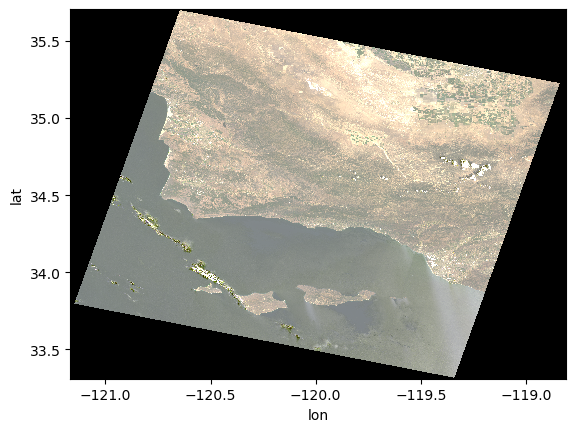

In [ ]:
full_xr.sel(band = ["red", "green", "blue"]).plot.imshow(robust= True)

In [ ]:
full_xr.sel(band = ["nir", "swir_1"])

<xarray.DataArray (lat: 7961, lon: 7831, band: 2)> Size: 249MB
array([[[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
...
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]]], dtype=uint16)
Coordinates:
  * lat      (lat) float64 64kB 35.71 35.71 35.71 35.71 ... 33.31 33.31 33.31
  * lon      (lon) float64 63kB -121.2 -121.2 -121.2 ... -118.8 -118.8 -118.8
  * band     (band) <U15 120B 'nir' 'swir_1'
Attributes:
    crs:          EPSG:4326
    description:  A full xarray for testing using landsat 8 data from july 2019.

In [ ]:
# File path to your MTL.txt
mtl_file_path = "/capstone/wildfire_prep/data/landsat/test/unpack/LC08_L2SP_042036_20190724_20200827_02_T1_MTL.txt"

# Initialize a dictionary to store reflectance scale factors
reflectance_scale_factors = {}

# Open and parse the file
with open(mtl_file_path, "r") as mtl_file:
    for line in mtl_file:
        # Check for reflectance scale multiplier keys
        if "REFLECTANCE_MULT_BAND" in line:
            key, value = line.strip().split(" = ")
            reflectance_scale_factors[key.strip()] = float(value)

print("Reflectance Scale Factors:")
print(reflectance_scale_factors)

for pair in zip(reflectance_scale_factors.keys(), reflectance_scale_factors.values()): 
    locals()[pair[0]] = pair[1]


Reflectance Scale Factors:
{'REFLECTANCE_MULT_BAND_1': 2e-05, 'REFLECTANCE_MULT_BAND_2': 2e-05, 'REFLECTANCE_MULT_BAND_3': 2e-05, 'REFLECTANCE_MULT_BAND_4': 2e-05, 'REFLECTANCE_MULT_BAND_5': 2e-05, 'REFLECTANCE_MULT_BAND_6': 2e-05, 'REFLECTANCE_MULT_BAND_7': 2e-05, 'REFLECTANCE_MULT_BAND_8': 2e-05, 'REFLECTANCE_MULT_BAND_9': 2e-05}


In [ ]:
REFLECTANCE_MULT_BAND_5

2e-05

In [ ]:
nir = full_xr.sel(band = "nir") * REFLECTANCE_MULT_BAND_5
swir = full_xr.sel(band = "swir_1") * REFLECTANCE_MULT_BAND_6

numerator = (nir - swir)
denominator = (nir + swir)

ndmi = (nir - swir) / (nir + swir)

# ndmi = np.where(
#     (nir > 0) & (swir > 0) & np.isfinite(nir) & np.isfinite(swir),
#     numerator / denominator,
#     np.nan
# )

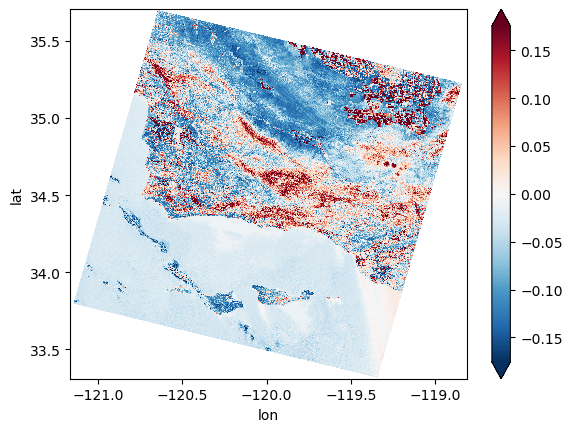

In [ ]:
ndmi.plot.imshow(robust=True)

In [ ]:
ndmi.shape

(7961, 7831)

In [ ]:
ndmi.where(np.isfinite(ndmi)).median()

<xarray.DataArray ()> Size: 8B
array(-0.02919568)

In [ ]:
list(reflectance_scale_factors.values())

[2e-05, 2e-05, 2e-05, 2e-05, 2e-05, 2e-05, 2e-05, 2e-05, 2e-05]

In [ ]:
for i in zip([2,6,1,5,135], [5,6,7,23,7]):
    print(i)

(2, 5)
(6, 6)
(1, 7)
(5, 23)
(135, 7)


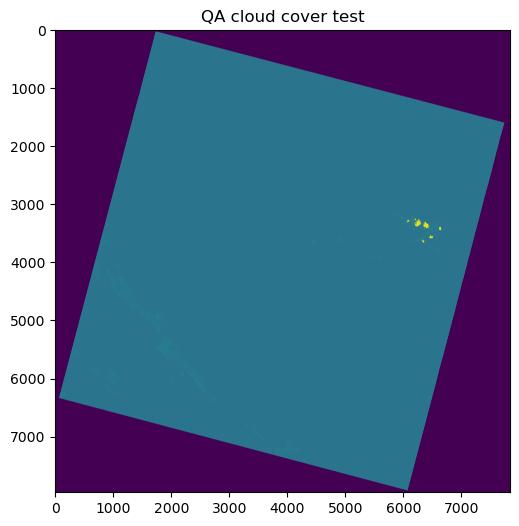

In [ ]:
with rio.open('/capstone/wildfire_prep/data/landsat/test/unpack/LC08_L2SP_042036_20190724_20200827_02_T1_QA_PIXEL.TIF', 'r') as src:
    qa = src.read().transpose((1,2,0))
    # np.transpose(image_data, (1, 2, 0))  # (height, width, bands)

plt.figure(figsize=(8, 6))
plt.imshow(qa)
plt.title("QA cloud cover test")
# plt.axis("off")  # Turn off axis for cleaner visualization
plt.show()


## Functions

In [ ]:
def extract_tar(tar_path, output_path): 
    
    with tar.open(tar_path, "r") as tar:
        tar.extractall(path = output_path)

    print(f"Files extracted to {output_direct}")


In [ ]:
def make_xr(landsat_filepath, filename, exp_path = "/capstone/wildfire_prep/data/landsat/test/export", regex = r'B\d|QA_[A-Za-z0-9_]+', new_crs = "EPSG:4326"):

    band_file_list = [] # init list to contain name of band files

    # check each file in the export filepath
    # for root, _, files in os.walk(landsat_filepath):
    #     for file in files:
    #         if fnmatch(file, str(regex)): # if it matches this specification
    #             band_file_list.append(file) # append it to the list

    for root, _, files in os.walk(landsat_filepath):
        for file in files:
            if fnmatch(file, "*SR*_B?.TIF"):
                band_file_list.append(file)
            elif fnmatch(file, "*QA*"): 
                band_file_list.append(file)
    

    

    # declaring variables with regex
    band_var_list = []

    for name in band_file_list:

        curr_path = root + "/" + name

        # Use regex to target certain parts of the filenames for the var names
        match = re.search(regex, name)

        # for each filename, grab the filename based off the regex
        if match:
            landsat_var_name = match.group() 

            # init the variable
            with rio.open(curr_path) as src:
                locals()[landsat_var_name] = src.read()

            # put every var into a list...
            band_var_list.append(landsat_var_name)

 




    # ...so we can set it into a B1, B2...B7, QAs order
    band_order_list = []

    # for ordering the QAs, we'll just do it from first to last declared
    error_i = 0

    # first we make numbered list based on locations of vars in var list
    for i in band_var_list:

        # if normal band
        try:
            rank = int(i[-1])
            band_order_list.append(rank)

        # if QA (can't convert a letter to an int)
        except ValueError:
            rank = 999 + error_i
            band_order_list.append(rank)
            error_i = error_i + 1




    # then we sort the var list and numbered list together
    presort = sorted(zip(band_var_list, band_order_list))
    band_var_list, band_order_list = [t[0] for t in presort], [t[1] for t in presort]



    # then we stack all bands together
    full_stack = np.stack([locals()[band] for band in band_var_list], axis=-1).squeeze()#.transpose((2,0,1))




    # do first export of stacked arrays to a tif
    filename = str(filename) # convert to str
    sample_path = landsat_filepath + "/" + band_file_list[0]
    tif_output_path = exp_path + "/" + filename

    with rio.open(sample_path) as src:
        height, width, bands = full_stack.shape
        crs = src.crs
        transform = src.transform
        dtype = full_stack.dtype

    # tif_output_path = export_path

    # f"/capstone/wildfire_prep/data/landsat/test/export/{filename}"

    # Write the 3D array as a GeoTIFF
    with rio.open(
        tif_output_path,
        "w",
        driver="GTiff",
        height=height,
        width=width,
        count=bands,  # Number of bands
        dtype=dtype,  # Data type of your array
        crs=crs,  # Coordinate Reference System
        transform=transform,  # Geotransform
    ) as dst:
        
        # Write each channel to a separate band
        for i in range(bands):
            dst.write(full_stack[:, :, i], indexes=i + 1)  # Band index starts at 1

    print(f"GeoTIFF created at: {tif_output_path}")


    # Open the GeoTIFF file
    with rio.open(tif_output_path) as src:
        transform = src.transform  # Affine transform
        crs = src.crs  # Coordinate Reference System
        full_tif = src.read()  # Shape: (7, height, width)




    # now we reproject the crs
    reproject_output_path = exp_path + "/reproject_" + filename
    # new_crs = "EPSG:4326"


    with rio.open(tif_output_path) as src: 

        # we are calculating new transform values here
        transform, width, height = calculate_default_transform(
            src_crs = src.crs, # original crs
            dst_crs = new_crs, # crs to reproject to
            width = src.width, height = src.height, # give it the original size

            # and the bounds
            left = src.bounds[0],
            bottom = src.bounds[1], 
            right = src.bounds[2], 
            top = src.bounds[3]
        )

        # then we update the metadata
        kwargs = src.meta.copy() # make a full copy
        kwargs.update({
            "crs": new_crs, 
            "transform": transform,
            "width": width,
            "height": height
        })


        # write the reprojected tif based on the edited metadata
        with rio.open(reproject_output_path, "w", **kwargs) as dst:

            # for every band in the tif
            for i in range(1, src.count + 1):
                reproject(
                    source = rio.band(src, i), # original band
                    destination = rio.band(dst, i), # new reprojected band
                    src_transform = src.transform, # old transform
                    src_crs = src.crs, # old crs
                    dst_transform = transform, # new transform
                    dst_crs = new_crs, # new crs
                    resampling = Resampling.nearest # resampling method
                )
    
    # Get the dimensions
    height, width, bands = full_stack.shape
    print(f"Image shape: {full_stack.shape}")

    # Generate pixel coordinate arrays
    y_indices, x_indices = np.arange(height), np.arange(width)


    # Calculate longitude (x) and latitude (y) values
    lon = transform.c + x_indices * transform.a  # Longitude array
    lat = transform.f + y_indices * transform.e  # Latitude array

    # Transpose the data from (bands, height, width) to (height, width, bands)
    full_data = np.transpose(full_stack, (0, 1, 2))  # Shape: (height, width, bands)


    


    # make the xarray.DataArray
    full_xr = xr.DataArray(
        data = full_data,
        dims = ("lat", "lon", "band"),
        coords = {
            "lat": lat,  # Latitude values
            "lon": lon,  # Longitude values
            "band": band_var_list  # Band names
        },
        attrs = {
            "crs": str(new_crs),  # Add CRS as metadata
            "description": "A full xarray for testing using landsat 8 data from july 2019."
        }
    )

    return full_xr

In [ ]:
full_xr = make_xr("/capstone/wildfire_prep/data/landsat/test/unpack", "test_export_tif.tif")

GeoTIFF created at: /capstone/wildfire_prep/data/landsat/test/export/test_export_tif.tif
Image shape: (7961, 7831, 10)


In [ ]:
def get_ndmi(mtl_fp = "/capstone/wildfire_prep/data/landsat/test/unpack/LC08_L2SP_042036_20190724_20200827_02_T1_MTL.txt", 
             xr_nir_band = full_xr.sel(band = "B5"), 
             xr_swir_band = full_xr.sel(band = "B6")):

    # Initialize a dictionary to store reflectance scale factors
    reflectance_scale_factors = {}

    # Open and parse the file
    with open(mtl_fp, "r") as mtl_file:
        for line in mtl_file:
            # Check for reflectance scale multiplier keys
            if "REFLECTANCE_MULT_BAND" in line:
                key, value = line.strip().split(" = ")
                reflectance_scale_factors[key.strip()] = float(value)

    print("Reflectance Scale Factors:")
    print(reflectance_scale_factors)

    for pair in zip(reflectance_scale_factors.keys(), reflectance_scale_factors.values()): 
        globals()[pair[0]] = pair[1]



    # calculate ndmi

    # modulate values by scaling value
    nir = xr_nir_band * REFLECTANCE_MULT_BAND_5
    swir = xr_swir_band * REFLECTANCE_MULT_BAND_6

    # build function and calculate
    numerator = (nir - swir)
    denominator = (nir + swir)

    ndmi = (nir - swir) / (nir + swir)

    return ndmi


In [ ]:
get_ndmi().to_pandas()

Reflectance Scale Factors:
{'REFLECTANCE_MULT_BAND_1': 2e-05, 'REFLECTANCE_MULT_BAND_2': 2e-05, 'REFLECTANCE_MULT_BAND_3': 2e-05, 'REFLECTANCE_MULT_BAND_4': 2e-05, 'REFLECTANCE_MULT_BAND_5': 2e-05, 'REFLECTANCE_MULT_BAND_6': 2e-05, 'REFLECTANCE_MULT_BAND_7': 2e-05, 'REFLECTANCE_MULT_BAND_8': 2e-05, 'REFLECTANCE_MULT_BAND_9': 2e-05}


lon,-121.166636,-121.166335,-121.166034,-121.165733,-121.165432,-121.165131,-121.164830,-121.164529,-121.164228,-121.163927,...,-118.811837,-118.811536,-118.811235,-118.810934,-118.810633,-118.810332,-118.810031,-118.809729,-118.809428,-118.809127
lat,,,,,,,,,,,,,,,,,,,,,
35.706298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35.705997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35.705696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35.705395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35.705094,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33.310852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33.310551,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33.310250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
REFLECTANCE_MULT_BAND_5

2e-05